# 📈 Notebook 3: Evaluación del Modelo

Este notebook cubre:
- Carga del modelo entrenado
- Evaluación en el conjunto de test
- Matriz de confusión
- Reporte de clasificación
- Análisis de errores
- Pruebas con imágenes individuales

In [13]:
# Imports
import sys
sys.path.append('..')

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.dataset.dataset import create_dataloaders
from src.models.classifier import MedicinalPlantClassifier
from src.models.train import evaluate_model
from src.utils.helpers import load_config, create_confusion_matrix

# Configuración
plt.rcParams['figure.figsize'] = (15, 10)

## 1. Configuración

In [14]:
# Cargar configuración
config = load_config('../config/config.yaml')

# Dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo: {device}")

Dispositivo: cpu


## 2. Cargar Datos de Test

In [15]:
# Crear DataLoaders
_, _, test_loader, class_names = create_dataloaders(
    train_dir='../data/processed/train',
    val_dir='../data/processed/val',
    test_dir='../data/processed/test',
    batch_size=32,
    image_size=224,
    num_workers=2,
    augment=False  # Sin augmentation para test
)

num_classes = len(class_names)
print(f"\nNúmero de clases: {num_classes}")
print(f"Imágenes de test: {len(test_loader.dataset)}")


DataLoaders creados:
Train: 13339 imágenes (417 batches)
Val:   3025 imágenes (95 batches)
Test:  3182 imágenes (100 batches)
Batch size: 32
Clases: 99


Número de clases: 99
Imágenes de test: 3182


## 3. Cargar Modelo Entrenado

In [16]:
# Cargar checkpoint
model_path = '../models/best_model.pth'

if not os.path.exists(model_path):
    print(f"❌ Error: No se encontró el modelo en {model_path}")
    print("   Entrena el modelo primero usando 02_entrenamiento_modelo.ipynb")
else:
    checkpoint = torch.load(model_path, map_location=device)
    
    # Crear modelo
    model = MedicinalPlantClassifier(
        num_classes=num_classes,
        architecture=config['model']['architecture'],
        pretrained=False
    )
    
    # Cargar pesos
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    print(f"✓ Modelo cargado desde: {model_path}")
    print(f"  - Época: {checkpoint.get('epoch', 'N/A')}")
    print(f"  - Val Accuracy: {checkpoint.get('val_acc', 'N/A'):.2f}%")

✓ Congeladas 110/158 capas (70.0%)
✓ Modelo cargado desde: ../models/best_model.pth
  - Época: 46
  - Val Accuracy: 98.51%


c:\Users\Deivid Cardenas\Music\pruebas\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Deivid Cardenas\Music\pruebas\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## 4. Evaluación en Test Set

In [17]:
# Evaluar modelo
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    device=device,
    class_names=class_names
)


Evaluando modelo en conjunto de Test



Testing:   0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Deivid Cardenas\Music\pruebas\venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Testing: 100%|██████████| 100/100 [01:05<00:00,  1.52it/s]


Resultados de Evaluación
Test Accuracy: 98.30%

Reporte de Clasificación:
                         precision    recall  f1-score   support

               Aloevera     0.9474    0.9474    0.9474        19
                   Amla     0.8462    1.0000    0.9167        11
           Amruthaballi     0.9333    1.0000    0.9655        28
                  Arali     1.0000    1.0000    1.0000        14
            Arive Dantu     1.0000    1.0000    1.0000        19
                  Arjun     1.0000    1.0000    1.0000       242
             Astma_weed     0.9286    1.0000    0.9630        13
               Badipala     1.0000    1.0000    1.0000        12
           Balloon_Vine     1.0000    1.0000    1.0000        10
                 Bamboo     0.9500    1.0000    0.9744        19
                 Basale     1.0000    1.0000    1.0000        16
                  Beans     1.0000    0.9375    0.9677        16
                  Betel     1.0000    0.9200    0.9583        25
              

## 5. Matriz de Confusión

Matriz de confusión guardada en: ../docs/confusion_matrix.png


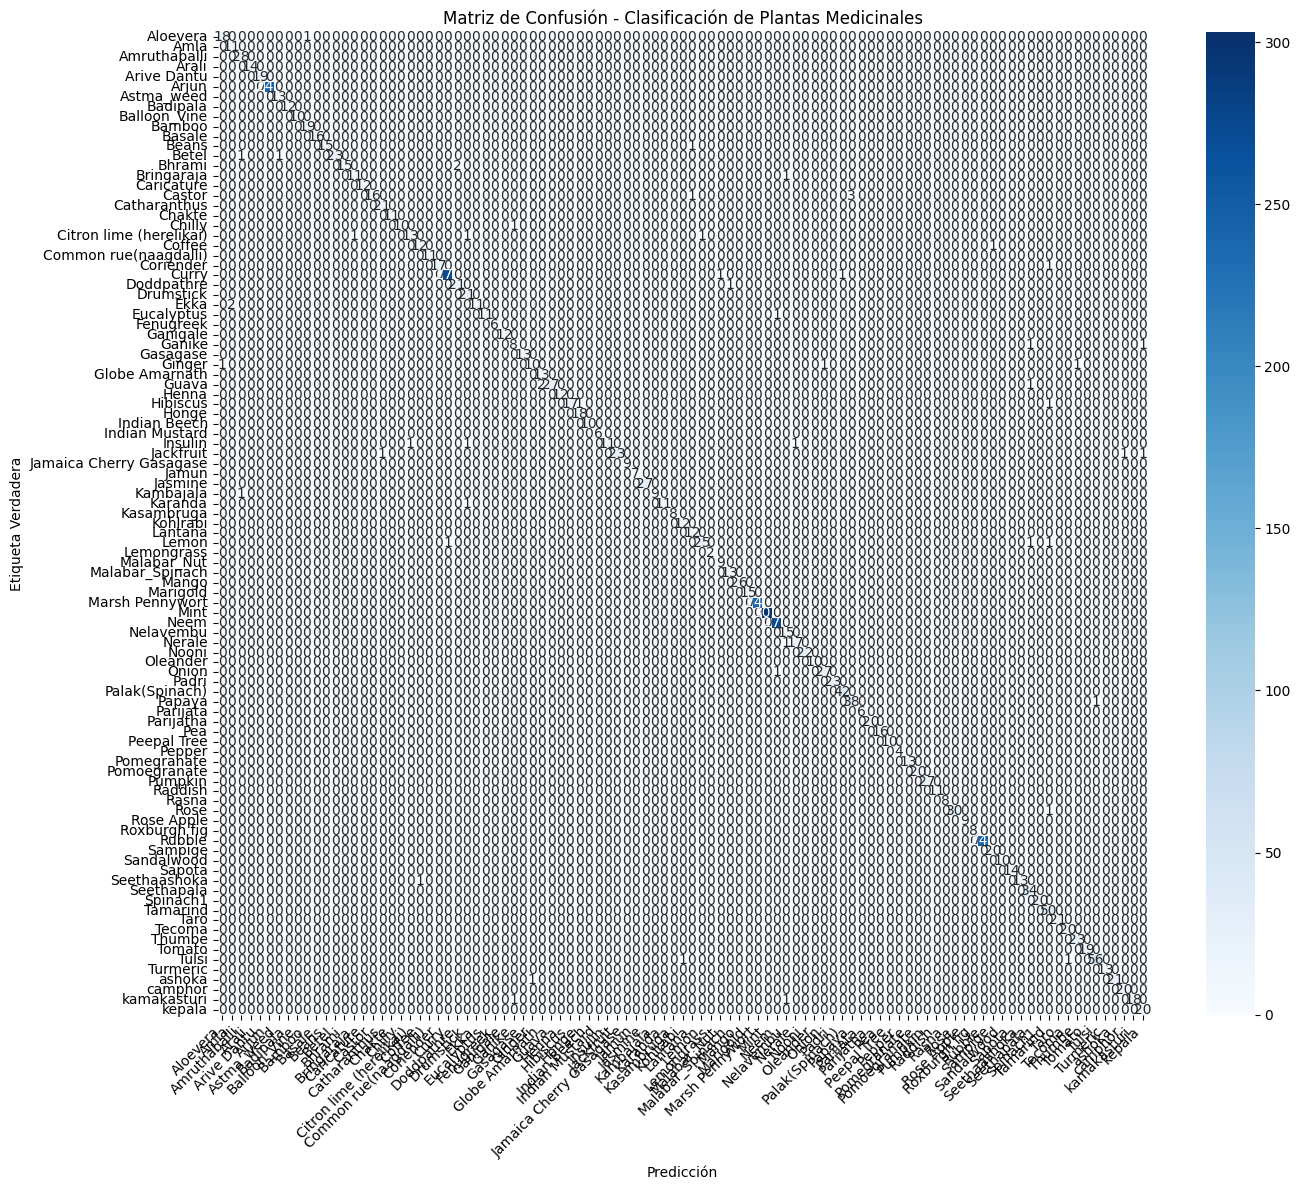

In [18]:
# Crear matriz de confusión
create_confusion_matrix(
    y_true=results['labels'],
    y_pred=results['predictions'],
    class_names=class_names,
    save_path='../docs/confusion_matrix.png',
    figsize=(14, 12)
)

## 6. Análisis de Errores

In [19]:
# Encontrar errores de clasificación
errors = []
for i, (true_label, pred_label) in enumerate(zip(results['labels'], results['predictions'])):
    if true_label != pred_label:
        errors.append({
            'index': i,
            'true': class_names[true_label],
            'predicted': class_names[pred_label]
        })

print(f"\nTotal de errores: {len(errors)} de {len(results['labels'])} imágenes")
print(f"Tasa de error: {100 * len(errors) / len(results['labels']):.2f}%")
print(f"\nPrimeros 10 errores:")
for i, error in enumerate(errors[:10]):
    print(f"  {i+1}. Verdadero: {error['true']:20} | Predicho: {error['predicted']}")


Total de errores: 54 de 3182 imágenes
Tasa de error: 1.70%

Primeros 10 errores:
  1. Verdadero: Aloevera             | Predicho: Bamboo
  2. Verdadero: Beans                | Predicho: Lantana
  3. Verdadero: Betel                | Predicho: Astma_weed
  4. Verdadero: Betel                | Predicho: Amruthaballi
  5. Verdadero: Bhrami               | Predicho: Doddpathre
  6. Verdadero: Bhrami               | Predicho: Doddpathre
  7. Verdadero: Bringaraja           | Predicho: Nelavembu
  8. Verdadero: Castor               | Predicho: Lantana
  9. Verdadero: Castor               | Predicho: Papaya
  10. Verdadero: Castor               | Predicho: Papaya


## 7. Análisis por Clase

In [20]:
# Calcular métricas por clase
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    results['labels'],
    results['predictions'],
    average=None
)

# Crear DataFrame para visualización
import pandas as pd

metrics_df = pd.DataFrame({
    'Clase': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

# Ordenar por F1-Score
metrics_df = metrics_df.sort_values('F1-Score', ascending=False)

print("\nMétricas por clase (ordenadas por F1-Score):")
print(metrics_df.to_string(index=False))


Métricas por clase (ordenadas por F1-Score):
                  Clase  Precision   Recall  F1-Score  Support
                  Arjun   1.000000 1.000000  1.000000      242
            Arive Dantu   1.000000 1.000000  1.000000       19
                  Arali   1.000000 1.000000  1.000000       14
               Ganigale   1.000000 1.000000  1.000000       12
              Fenugreek   1.000000 1.000000  1.000000        6
               Gasagase   1.000000 1.000000  1.000000       13
               Badipala   1.000000 1.000000  1.000000       12
                 Basale   1.000000 1.000000  1.000000       16
           Balloon_Vine   1.000000 1.000000  1.000000       10
             Caricature   1.000000 1.000000  1.000000       12
                 Chakte   1.000000 1.000000  1.000000       11
  Common rue(naagdalli)   1.000000 1.000000  1.000000       11
                Raddish   1.000000 1.000000  1.000000       11
                  Rasna   1.000000 1.000000  1.000000        8
         

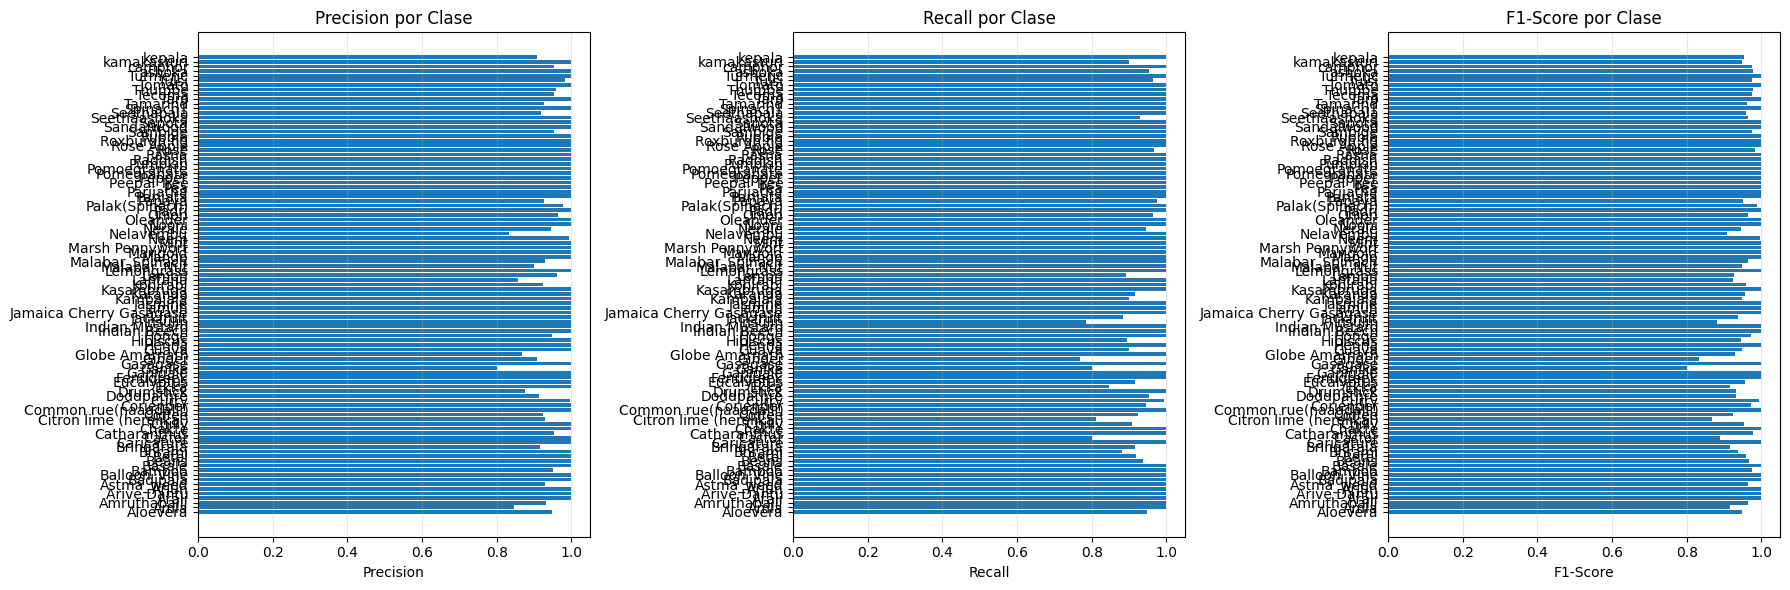

In [21]:
# Visualizar métricas por clase
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision
axes[0].barh(range(len(class_names)), precision)
axes[0].set_yticks(range(len(class_names)))
axes[0].set_yticklabels(class_names)
axes[0].set_xlabel('Precision')
axes[0].set_title('Precision por Clase')
axes[0].grid(axis='x', alpha=0.3)

# Recall
axes[1].barh(range(len(class_names)), recall)
axes[1].set_yticks(range(len(class_names)))
axes[1].set_yticklabels(class_names)
axes[1].set_xlabel('Recall')
axes[1].set_title('Recall por Clase')
axes[1].grid(axis='x', alpha=0.3)

# F1-Score
axes[2].barh(range(len(class_names)), f1)
axes[2].set_yticks(range(len(class_names)))
axes[2].set_yticklabels(class_names)
axes[2].set_xlabel('F1-Score')
axes[2].set_title('F1-Score por Clase')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/metrics_per_class.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Prueba con Imagen Individual

In [22]:
# Función para predecir una imagen
from torchvision import transforms

def predict_image(image_path, model, class_names, device, top_k=3):
    """Predice la clase de una imagen."""
    # Transformaciones
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    # Cargar imagen
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Predicción
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        
    # Top K predicciones
    top_probs, top_indices = probabilities.topk(top_k, dim=1)
    
    # Resultados
    results = []
    for i in range(top_k):
        idx = top_indices[0][i].item()
        prob = top_probs[0][i].item()
        results.append({
            'class': class_names[idx],
            'probability': prob * 100
        })
    
    return image, results

# Ejemplo de uso
# Descomenta y cambia la ruta a una imagen de test
# test_image_path = '../data/processed/test/aloe_vera/img_001.jpg'
# image, predictions = predict_image(test_image_path, model, class_names, device)

# # Visualizar
# plt.figure(figsize=(10, 6))
# plt.imshow(image)
# plt.axis('off')
# plt.title(f"Predicción: {predictions[0]['class']} ({predictions[0]['probability']:.1f}%)")
# plt.show()

# print("\nTop 3 predicciones:")
# for i, pred in enumerate(predictions):
#     print(f"{i+1}. {pred['class']:20} - {pred['probability']:.2f}%")

## 9. Resumen de Evaluación

In [23]:
print("\n" + "="*70)
print("RESUMEN DE EVALUACIÓN")
print("="*70)
print(f"Test Accuracy: {results['accuracy']:.2f}%")
print(f"Total de imágenes: {len(results['labels'])}")
print(f"Errores: {len(errors)}")
print(f"Tasa de error: {100 * len(errors) / len(results['labels']):.2f}%")
print(f"\nPrecision promedio: {precision.mean():.4f}")
print(f"Recall promedio: {recall.mean():.4f}")
print(f"F1-Score promedio: {f1.mean():.4f}")
print("="*70)


RESUMEN DE EVALUACIÓN
Test Accuracy: 98.30%
Total de imágenes: 3182
Errores: 54
Tasa de error: 1.70%

Precision promedio: 0.9737
Recall promedio: 0.9702
F1-Score promedio: 0.9707


## 10. Próximos Pasos

1. ✅ Modelo evaluado en conjunto de test
2. ✅ Métricas calculadas y visualizadas
3. ➡️ Probar el modelo en la aplicación Flask:
   ```bash
   python app/app.py
   ```
4. ➡️ Preparar documentación y reporte final

In [24]:
print("\n✓ Evaluación completada")
print("\nPróximo paso: Ejecutar la aplicación Flask")
print("  python app/app.py")


✓ Evaluación completada

Próximo paso: Ejecutar la aplicación Flask
  python app/app.py
